## Clustering

El objetivo de esta fase es la ingeniería de una variable objetivo (target) robusta, denominada deal_score, destinada al modelado predictivo del valor de un inmueble. Se desestima el uso del precio absoluto en favor de una métrica de valor relativo, la cual ofrece una mayor capacidad de generalización y una interpretación más significativa en el contexto del mercado.

El diseño de esta variable se fundamenta en un principio central de la valoración inmobiliaria: el valor de una propiedad se determina principalmente por su ubicación. Por tanto, el deal_score se define como la desviación porcentual del precio por metro cuadrado (priceByArea) de un inmueble con respecto a la mediana de precios de su micromercado de referencia. Esta normalización permite una comparación equitativa entre activos de distintas dimensiones y contextualiza su valor en el entorno geográfico inmediato, que constituye el factor más influyente en su cotización.

La delimitación precisa de estos micromercados geográficos es un paso crítico. Con el fin de identificar la estrategia de zonificación más efectiva, se propone un análisis comparativo de tres metodologías distintas:

- **Agrupamiento Basado en Centroides:** Implementado mediante el algoritmo K-Means.

- **Agrupamiento Basado en Densidad:** Implementado mediante el algoritmo DBSCAN.

- **Segmentación Administrativa:** Utilizando los límites de distritos oficiales.

Cada una de estas estrategias será evaluada mediante criterios cuantitativos y cualitativos para determinar su idoneidad. La metodología de zonificación que demuestre la mayor coherencia y capacidad de discriminación será seleccionada para generar la versión definitiva de la variable deal_score, concluyendo así la preparación del conjunto de datos para la subsecuente fase de modelado predictivo.

In [24]:
!pip install kmodes

# Análisis de datos y computación numérica
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning y Preprocesamiento
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from kmodes.kprototypes import KPrototypes

# Visualización Geográfica
import folium
from folium.plugins import MarkerCluster
from branca.colormap import LinearColormap

In [25]:
#Carpeta de ficheros_csv del drive
!gdown --folder -q https://drive.google.com/drive/folders/1GcfvHOr_N3NyKCmp6w1dX6HJ2JRfO1mD?usp=drive_link

In [26]:
# Carga de datos
df_limpios = pd.read_csv("/content/Ficheros CSV/_20250910_dataset_features_model.csv")
df_limpios = df_limpios.drop(columns=['text'])

## Estrategia 1: Clustering basado en centroides (KMeans)

La primera metodología de zonificación evaluada se basa en el algoritmo de agrupamiento por centroides K-Means. Este es un método de aprendizaje no supervisado cuyo objetivo es particionar un conjunto de n observaciones en k conglomerados (clusters), en el cual cada observación pertenece al grupo cuyo centroide (media) es el más cercano. El proceso es de naturaleza iterativa: los centroides se recalculan sucesivamente hasta que su posición converge, minimizando así la varianza intra-cluster.

Para la presente aplicación, el algoritmo K-Means se aplicó exclusivamente sobre el subconjunto de características geográficas: latitud, longitud y distancia_al_centro. El propósito es identificar agrupaciones de propiedades que sean espacialmente cohesivas, generando así micromercados definidos por su proximidad geométrica en lugar de por límites administrativos.

#### 1.1.a. Feature Engineering
Previo a la fase de agrupamiento, se llevó a cabo un proceso de ingeniería de características (feature engineering) con el fin de enriquecer el conjunto de datos. Este proceso se centró en la creación de nuevas variables con un mayor poder informativo y contextual que las características originales.

Específicamente, se generaron las siguientes métricas:

- Una métrica de centralidad geográfica (distancia_al_centro), calculada como la distancia euclidiana de cada inmueble al centro geográfico de la ciudad.

- Ratios de valor y dimensión normalizados, tales como price_per_room y size_per_room, para permitir comparaciones de eficiencia de espacio y coste entre propiedades de distintas tipologías.

- Un índice agregado de calidad (amenities_score), que cuantifica el valor y la cantidad de las comodidades y características adicionales del inmueble.

El propósito de esta etapa es transformar los datos brutos en un conjunto de características más robusto y discriminativo, optimizando así la base de información para las fases subsecuentes de modelado.

In [27]:
# Features Geográficas

# Coordenadas referencia (Puerta del Sol)
lat_centro, lon_centro = 40.416775, -3.703790

# Distancia euclidiana
df_limpios['distancia_al_centro'] = np.sqrt(
    (df_limpios['latitude'] - lat_centro)**2 + (df_limpios['longitude'] - lon_centro)**2
) * 111.32

# Features de Valor y Calidad

# Ratios para normalizar por habitación
df_limpios['price_per_room'] = df_limpios['price'] / df_limpios['rooms'].replace(0, 1)
df_limpios['size_per_room'] = df_limpios['size'] / df_limpios['rooms'].replace(0, 1)

# Puntuación sumando comodidades (columnas binarias 0/1)
amenities_cols = [
    'exterior', 'hasLift', 'parkingSpace.hasParkingSpace', 'newDevelopment',
    'has360', 'has3DTour', 'hasPlan', 'hasStaging', 'hasVideo', 'score_final'
]
df_limpios['amenities_score'] = df_limpios[amenities_cols].sum(axis=1)

#### 1.1.b. Número óptimo de Clusters
Un paso preliminar y metodológicamente crucial en la aplicación del algoritmo K-Means es la determinación del número óptimo de clústeres (k). Para este fin, se emplearon dos métricas de evaluación complementarias: el método del codo, que analiza la reducción de la inercia intra-clúster, y la puntuación de silueta, que mide la cohesión y separación de los grupos.

El objetivo de este análisis dual es asegurar que la segmentación geográfica resultante sea estadísticamente coherente y representativa de la estructura espacial de los datos.

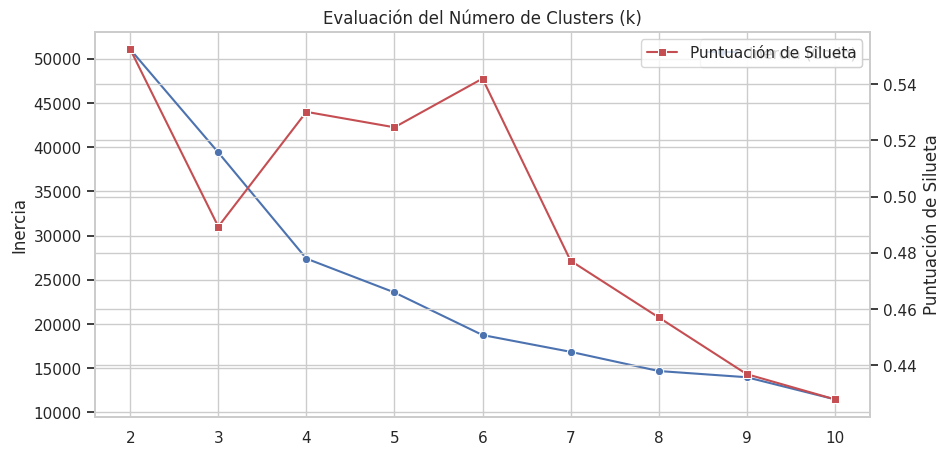

In [28]:
# Seleccionar y escalar variables para el clustering geográfico
geo_features = ['latitude', 'longitude', 'distancia_al_centro']
X_geo = df_limpios[geo_features]
scaler = StandardScaler()
X_geo_scaled = scaler.fit_transform(X_geo)

# Encontrar el número óptimo de clusters (k)
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_geo_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_geo_scaled, kmeans.labels_))

# Visualizar los resultados para decidir k
plt.figure(figsize=(10, 5))
sns.lineplot(x=k_range, y=inertia_values, marker='o', label='Inercia (Codo)')
plt.ylabel('Inercia')
plt.twinx()
sns.lineplot(x=k_range, y=silhouette_scores, marker='s', color='r', label='Puntuación de Silueta')
plt.ylabel('Puntuación de Silueta')
plt.title('Evaluación del Número de Clusters (k)')
plt.grid(True)
plt.show()



#### 1.1.c. Generación de deal_scores para Múltiples k

Se evaluó el impacto de la granularidad en la zonificación aplicando el algoritmo K-Means de forma iterativa para un rango de valores k [6, 15, 30, 50, 200].

A pesar de que las métricas estadísticas sugerían una eficiencia óptima en k=6, se priorizó un criterio de dominio. Se postuló que un valor bajo de k produciría "macro-zonas" internamente heterogéneas, enmascarando las dinámicas de precios locales. Por el contrario, la exploración de valores de k superiores buscaba definir "micro-zonas" con una mayor homogeneidad interna, más representativas de la segmentación real del mercado.

In [29]:
# Generación de clusters y deal_scores con k=6, 15, 30, 50 y 200 ---

k_values = [6, 15, 30, 50, 200]

# Entrenar el modelo KMeans para cada k
for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    df_limpios[f'zona_cluster_k{k}'] = kmeans.fit_predict(X_geo_scaled)

    # Calcular la mediana del precio para cada nuevo conjunto de clusters
    median_price_col = f'median_price_k{k}'
    df_limpios[median_price_col] = df_limpios.groupby(f'zona_cluster_k{k}')['priceByArea'].transform('median')

    # Calcular el deal_score para cada k
    deal_score_col = f'deal_score_k{k}'
    df_limpios[deal_score_col] = (df_limpios['priceByArea'] - df_limpios[median_price_col]) / df_limpios[median_price_col]

cols_to_show = [f'deal_score_k{k}' for k in k_values]
print("Muestra de los 'deal_scores' generados:")
print(df_limpios[cols_to_show].head())

Muestra de los 'deal_scores' generados:
   deal_score_k6  deal_score_k15  deal_score_k30  deal_score_k50  \
0       0.342317        0.038462       -0.087090        0.157644   
1      -0.091229       -0.296944       -0.381944       -0.216255   
2       0.342317        0.038462       -0.087090        0.157644   
3       0.260462        0.271101        0.556428        0.344403   
4       1.003348        2.786144        1.478873        1.347818   

   deal_score_k200  
0         0.156309  
1        -0.217159  
2         0.156309  
3         0.275731  
4         1.234086  


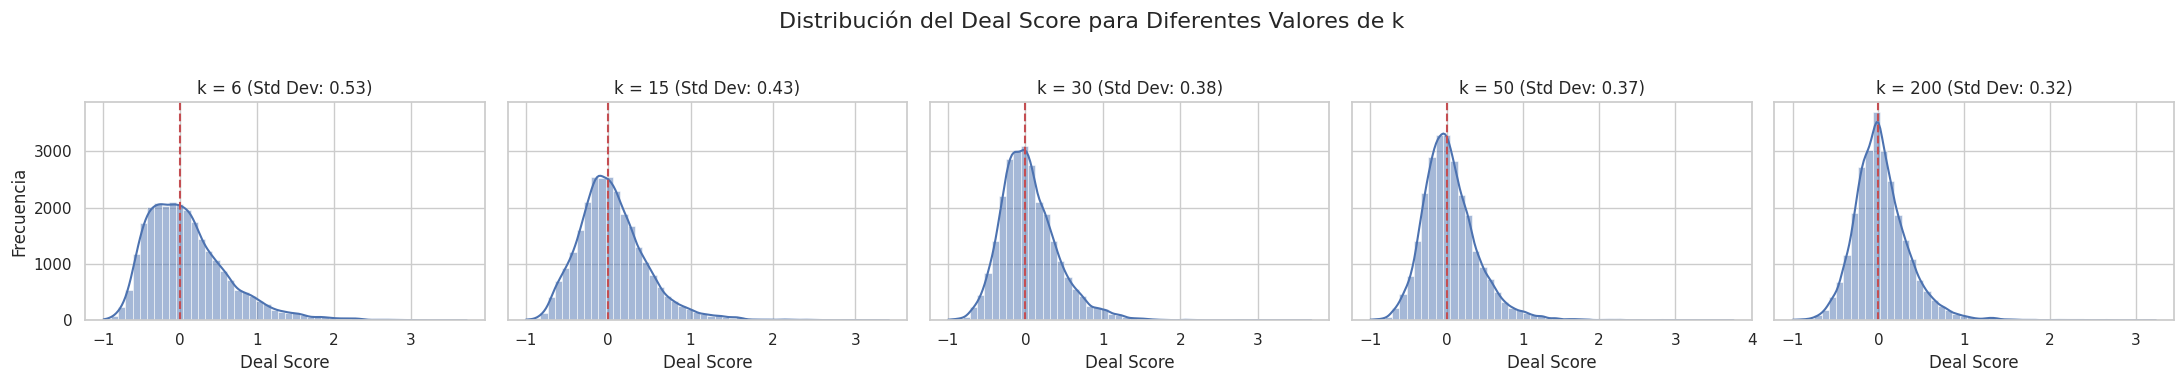


Descripción estadística de cada Deal Score:
       deal_score_k6  deal_score_k15  deal_score_k30  deal_score_k50  \
count   26261.000000    26261.000000    26261.000000    26261.000000   
mean        0.087456        0.050566        0.049745        0.047132   
std         0.533009        0.427199        0.375713        0.366392   
min        -0.999151       -0.999231       -0.999249       -0.999253   
25%        -0.301640       -0.227357       -0.203097       -0.191671   
50%         0.000000        0.000000        0.000000        0.000000   
75%         0.359558        0.268743        0.249545        0.234595   
max         3.730187        3.409164        3.692073        3.762599   

       deal_score_k200  
count     26261.000000  
mean          0.035520  
std           0.324950  
min          -0.999332  
25%          -0.170897  
50%           0.000000  
75%           0.196981  
max           3.233838  


In [30]:

#Comparación visual de las distribuciones de deal_score

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
fig.suptitle('Distribución del Deal Score para Diferentes Valores de k', fontsize=16)

# Lista de k y las columnas correspondientes
deal_score_cols = [f'deal_score_k{k}' for k in k_values]

for i, col in enumerate(deal_score_cols):
    # Crear histograma
    sns.histplot(ax=axes[i], data=df_limpios, x=col, kde=True, bins=50)
    axes[i].axvline(0, color='r', linestyle='--')

    # Calcular desviación estándar
    std_dev = df_limpios[col].std()
    axes[i].set_title(f'k = {k_values[i]} (Std Dev: {std_dev:.2f})')
    axes[i].set_xlabel('Deal Score')

axes[0].set_ylabel('Frecuencia')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Show
print("\nDescripción estadística de cada Deal Score:")
print(df_limpios[deal_score_cols].describe())

### 1.2. Selección para el Clustering

Tras el análisis comparativo, se ha seleccionado k=50 como el número óptimo de clústeres para la zonificación geoespacial. Esta decisión representa el equilibrio más efectivo entre la granularidad de la segmentación y la robustez estadística de los grupos resultantes.

Se determinó que valores bajos de k (e.g., k=6) generaban "macro-zonas" que ocultaban la heterogeneidad de precios a nivel local. Por el contrario, valores muy elevados (k=200) introducían el riesgo de crear clústeres con un soporte muestral insuficiente, aumentando la inestabilidad.

El valor k=50 fue, por tanto, identificado como el punto a partir del cual las ganancias en homogeneidad intra-clúster se volvían marginales. Esta zonificación empírica será posteriormente contrastada con la segmentación por límites administrativos para validar su superioridad predictiva.

#### Visualizacion del clustering

In [31]:
def visualizar_clusters_en_mapa(df, k):
    """
    Genera un mapa de Folium visualizando los clusters para un valor k específico.

    Args:
        df (pd.DataFrame):
        k (int): El número de clusters.
    """
    # Construye el nombre de la columna dinámicamente a partir de k
    cluster_col = f'zona_cluster_k{k}'

    # Mapa base centrado en Madrid
    mapa = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=11)

    # Paleta de colores
    num_clusters = df[cluster_col].nunique()
    colors = sns.color_palette('bright', n_colors=num_clusters).as_hex()

    # Añadir puntos al mapa
    sample_size = df.shape[0]
    df_sample = df.sample(n=sample_size, random_state=42)

    for index, row in df_sample.iterrows():
        cluster_id = row[cluster_col]

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color=colors[cluster_id],
            fill=True,
            fill_color=colors[cluster_id],
            fill_opacity=0.6,
            popup=f"Zona k={k}: {cluster_id}<br>Precio: {row['price']:,.0f} €"
        ).add_to(mapa)

    return mapa

mapa_k50 = visualizar_clusters_en_mapa(df_limpios, 50) #Cambiar el valor a uno de los calculados antes por si quieres comparar
mapa_k50

Output hidden; open in https://colab.research.google.com to view.

### 1.3. Creación de la Variable Objetivo (deal_score con k=50)

Una vez seleccionada la partición óptima de k=50, se procedió a la ingeniería de la variable objetivo final, denominada deal_score_k50.

Para cada uno de los 50 clústeres, se determinó primero un precio de mercado de referencia, definido como la mediana del priceByArea de todos los inmuebles de dicho grupo. Posteriormente, el deal_score de cada inmueble se calculó como la desviación porcentual de su priceByArea respecto a la mediana de su clúster asignado.

De este modo, un valor negativo en la variable deal_score_k50 indica que un activo se encuentra infravalorado en relación con su micromercado local, mientras que un valor positivo denota un sobreprecio.

In [32]:
# Precio mediano por metro cuadrado para cada una de las zonas
df_limpios['median_price_k50'] = df_limpios.groupby('zona_cluster_k50')['priceByArea'].transform('median')

# deal_score' basado en los clusters de k=50
df_limpios['deal_score_k50'] = (df_limpios['priceByArea'] - df_limpios['median_price_k50']) / df_limpios['median_price_k50']

print("Verificación de las nuevas columnas (k=50):")
cols_to_show = ['zona_cluster_k50', 'priceByArea', 'median_price_k50', 'deal_score_k50']
print(df_limpios[cols_to_show].head())

print("\n--- Top 5 Mejores Ofertas (k=50) ---")
print(df_limpios.nsmallest(5, 'deal_score_k50')[cols_to_show])

print("\n--- Top 5 Peores Ofertas (k=50) ---")
print(df_limpios.nlargest(5, 'deal_score_k50')[cols_to_show])

Verificación de las nuevas columnas (k=50):
   zona_cluster_k50  priceByArea  median_price_k50  deal_score_k50
0                37       8019.0            6927.0        0.157644
1                37       5429.0            6927.0       -0.216255
2                37       8019.0            6927.0        0.157644
3                23       7530.0            5601.0        0.344403
4                 0      11968.0            5097.5        1.347818

--- Top 5 Mejores Ofertas (k=50) ---
       zona_cluster_k50  priceByArea  median_price_k50  deal_score_k50
25485                12          2.0            2676.0       -0.999253
25443                12          3.0            2676.0       -0.998879
25452                12          3.0            2676.0       -0.998879
14152                32         28.0            2468.0       -0.988655
12383                 6         17.0            1407.5       -0.987922

--- Top 5 Peores Ofertas (k=50) ---
       zona_cluster_k50  priceByArea  median_price_k5

#### Visualización del deal_score

/tmp/ipython-input-227186890.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


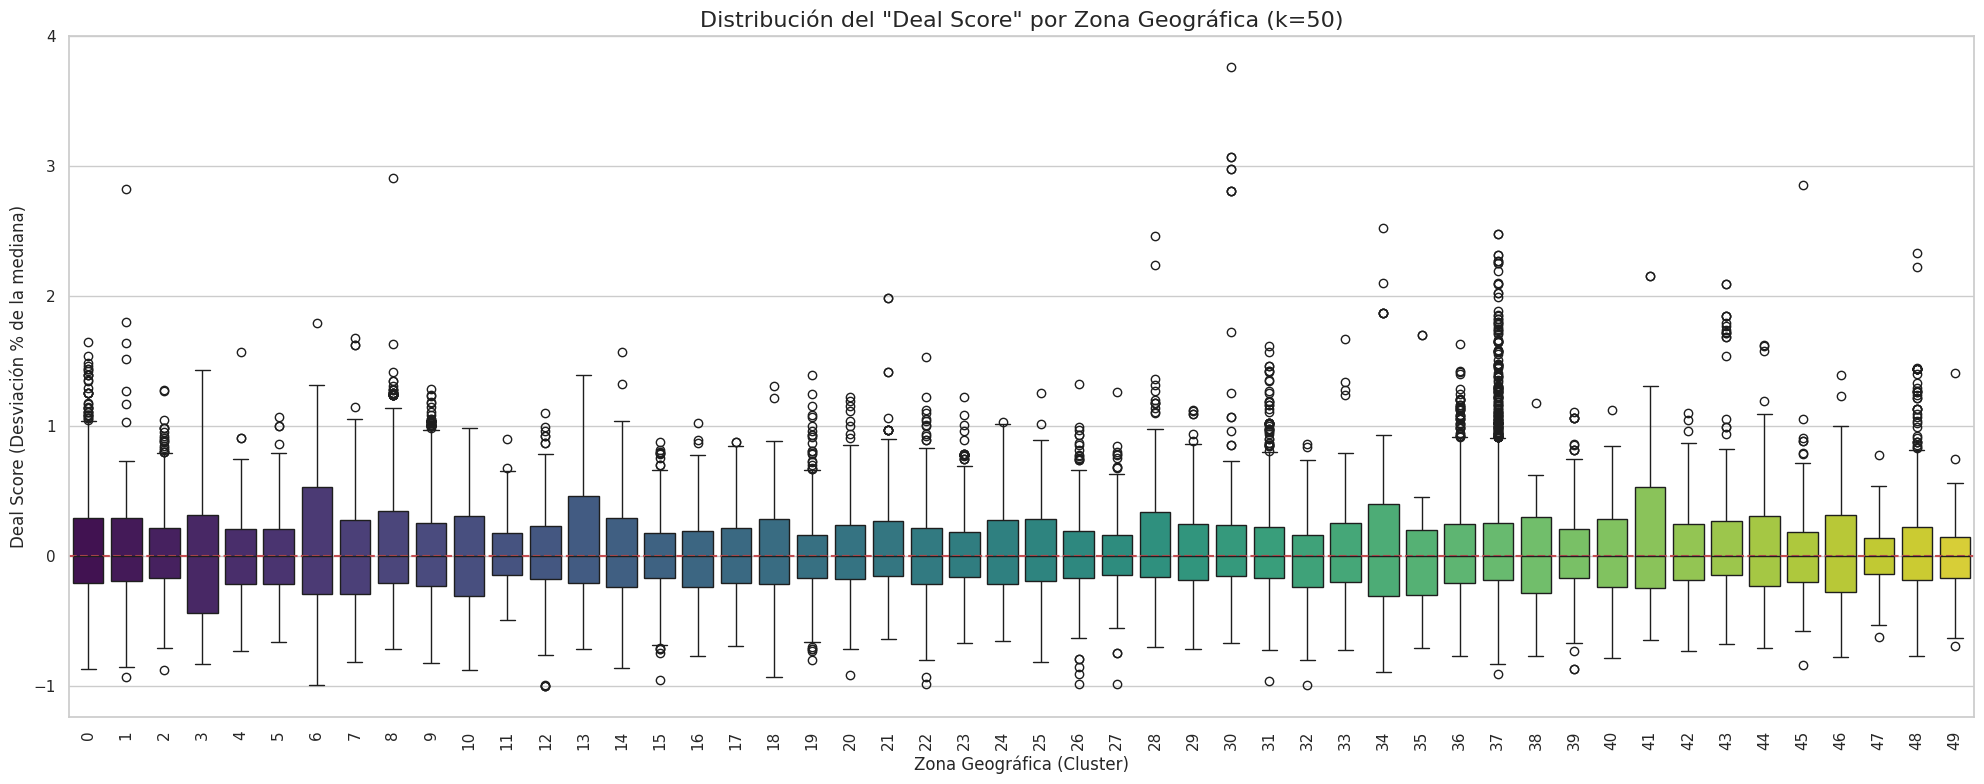

In [33]:
plt.figure(figsize=(20, 8))
sns.set(style="whitegrid")

# Boxplot
ax = sns.boxplot(
    x='zona_cluster_k50',
    y='deal_score_k50',
    data=df_limpios,
    palette='viridis'
)

ax.axhline(0, color='r', linestyle='--')

plt.title('Distribución del "Deal Score" por Zona Geográfica (k=50)', fontsize=16)
plt.xlabel('Zona Geográfica (Cluster)')
plt.ylabel('Deal Score (Desviación % de la mediana)')

if df_limpios['zona_cluster_k50'].nunique() > 25:
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Opcion 2, DBSCAN

La segunda estrategia de zonificación evaluada es DBSCAN (Density-Based Spatial Clustering of Applications with Noise), un algoritmo de agrupamiento basado en densidad. A diferencia de los métodos basados en centroides, DBSCAN no requiere la predefinición del número de clústeres y es capaz de identificar conglomerados de geometría arbitraria, una ventaja significativa en el análisis de datos geoespaciales.  Adicionalmente, el algoritmo clasifica de forma inherente las observaciones que no pertenecen a ningún grupo denso como anomalías o "ruido".

La parametrización del modelo se centra en la estimación del radio de vecindad (eps). Este valor se determinó mediante un análisis del gráfico de k-distancia (k-distance plot), una técnica estándar para identificar el radio óptimo que mejor se ajusta a la estructura de densidad intrínseca de los datos.

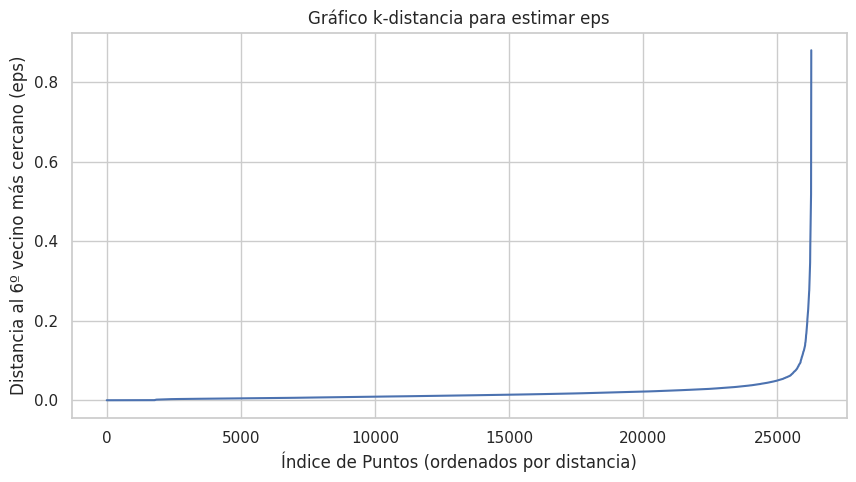

In [34]:
# Encontrar el parámetro 'eps' óptimo. (Usamos NearestNeighbors para calcular la distancia al k-ésimo vecino más cercano)
# Un buen punto de partida para 'min_samples' es 2 * número_de_features (en este caso, 2*3=6).

nn = NearestNeighbors(n_neighbors=6)
nbrs = nn.fit(X_geo_scaled) # Reutilizamos los datos geográficos escalados
distances, indices = nbrs.kneighbors(X_geo_scaled)

# Ordenamos y graficamos las distancias al 6º vecino (El punto de máxima curvatura ("codo") en este gráfico es un buen candidato para 'eps')
sorted_distances = np.sort(distances[:, 5]) # Distancias al 6º vecino (índice 5)

plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.title("Gráfico k-distancia para estimar eps")
plt.xlabel("Índice de Puntos (ordenados por distancia)")
plt.ylabel("Distancia al 6º vecino más cercano (eps)")
plt.grid(True)
plt.show()

In [35]:
# Aplicar DBSCAN con los parámetros optimos (0.18)
optimal_eps = 0.18

dbscan = DBSCAN(eps=optimal_eps, min_samples=6)
df_limpios['zona_cluster_dbscan'] = dbscan.fit_predict(X_geo_scaled)


# Analizar resultados del clustering
print("Distribución de inmuebles por cluster (DBSCAN):")
print(df_limpios['zona_cluster_dbscan'].value_counts())

# Calcular el 'deal_score' para los clusters de DBSCAN
median_prices_dbscan = df_limpios[df_limpios['zona_cluster_dbscan'] != -1].groupby('zona_cluster_dbscan')['priceByArea'].transform('median')

# Columna de mediana, que será NaN para los outliers (cluster -1)
df_limpios['median_price_dbscan'] = np.nan
df_limpios.loc[df_limpios['zona_cluster_dbscan'] != -1, 'median_price_dbscan'] = median_prices_dbscan

# El 'deal_score' será NaN para los outliers
df_limpios['deal_score_dbscan'] = (df_limpios['priceByArea'] - df_limpios['median_price_dbscan']) / df_limpios['median_price_dbscan']

# Verificación
print("\nMuestra del 'deal_score' para DBSCAN (excluyendo outliers):")
cols_to_show = ['zona_cluster_dbscan', 'priceByArea', 'median_price_dbscan', 'deal_score_dbscan']
print(df_limpios[df_limpios['zona_cluster_dbscan'] != -1][cols_to_show].head())

Distribución de inmuebles por cluster (DBSCAN):
zona_cluster_dbscan
0     19589
3       748
5       566
9       342
1       319
      ...  
92        6
67        6
88        6
94        6
97        6
Name: count, Length: 99, dtype: int64

Muestra del 'deal_score' para DBSCAN (excluyendo outliers):
   zona_cluster_dbscan  priceByArea  median_price_dbscan  deal_score_dbscan
0                    0       8019.0               5180.0           0.548069
1                    0       5429.0               5180.0           0.048069
2                    0       8019.0               5180.0           0.548069
3                    0       7530.0               5180.0           0.453668
4                    0      11968.0               5180.0           1.310425


In [36]:
#Visualización DBSCAN con Leyenda y Colores Corregidos ---

# Mapa base
mapa_dbscan_legend = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# Paleta y mapa de colores
cluster_labels = df_limpios['zona_cluster_dbscan'].unique()
num_real_clusters = len([label for label in cluster_labels if label != -1])

colors = sns.color_palette('hsv', n_colors=num_real_clusters).as_hex()
color_map = {label: colors[i] for i, label in enumerate(sorted([l for l in cluster_labels if l != -1]))}
color_map[-1] = '#808080' # Gris para el ruido

# Añadir puntos al mapa
sample_size = min(len(df_limpios), 7000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    cluster_id = row['zona_cluster_dbscan']
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=color_map.get(cluster_id),
        fill=True,
        fill_color=color_map.get(cluster_id),
        fill_opacity=0.7 if cluster_id != -1 else 0.3,
        popup=f"Zona DBSCAN: {cluster_id}"
    ).add_to(mapa_dbscan_legend)

# Crear y añadir leyenda (los 5 clusteres más grandes)
top5_clusters = df_limpios[df_limpios['zona_cluster_dbscan'] != -1]['zona_cluster_dbscan'].value_counts().nlargest(5).index

legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 200px; height: auto;
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; opacity: 0.9;
            ">&nbsp;<b>Leyenda de Zonas (DBSCAN)</b><br>
'''

for cluster_id in sorted(top5_clusters):
    color = color_map[cluster_id]
    legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color}"></i>&nbsp; Zona {cluster_id}<br>'

legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color_map[-1]}"></i>&nbsp; Ruido (Outliers)<br>'
legend_html += '&nbsp; ... y otros clusters<br></div>'

mapa_dbscan_legend.get_root().html.add_child(folium.Element(legend_html))

mapa_dbscan_legend

Output hidden; open in https://colab.research.google.com to view.

### Análisis Comparativo y Selección de Metodología

El análisis comparativo de las dos estrategias de agrupamiento revela una clara superioridad del algoritmo *K-Means* para el objetivo específico de este proyecto. La siguiente tabla resume la evaluación de cada método según los criterios definidos:

| Criterio de Evaluación | K-Means (*k*=50) | DBSCAN | Idoneidad para el Objetivo |
| :--- | :--- | :--- | :--- |
| **Granularidad de Zonas** | Óptima (50 clústeres homogéneos) | Deficiente (un clúster dominante) | **K-Means** |
| **Utilidad para `deal_score`** | Alta (referencias de precios locales) | Baja (referencia de precio única) | **K-Means** |
| **Detección de Anomalías** | No aplicable | Superior (aislamiento de *outliers*) | **DBSCAN** |

Si bien *DBSCAN* demostró su capacidad teórica para la detección de anomalías, su aplicación práctica resultó en la generación de un único conglomerado dominante. Este "super-clúster" agrupa zonas con dinámicas de mercado marcadamente dispares, lo que invalida el cálculo de una mediana de precios representativa y, por ende, la utilidad de un `deal_score` derivado.

En contraste, la partición generada por *K-Means* con *k*=50 produce una segmentación del mercado en 50 micro-zonas con una coherencia interna de precios notablemente superior. Esta granularidad es el factor determinante de su idoneidad, ya que permite el cálculo de precios de referencia locales y fiables.

Por consiguiente, se concluye que la segmentación producida por *K-Means* es la más adecuada para este caso de uso. El análisis subsecuente procederá utilizando la variable `deal_score_k50`.

## Opcion 3, Distritos

La tercera estrategia de zonificación evaluada utiliza los límites administrativos oficiales de los distritos. Este enfoque no es algorítmico, sino que funciona como un benchmark o punto de referencia, empleando una partición del mercado preexistente y de alta interpretabilidad.

El objetivo es determinar si la claridad de esta segmentación compensa su principal desventaja teórica: una potencial heterogeneidad de precios intra-distrito. El rendimiento del deal_score derivado de los distritos se contrastará con el obtenido mediante los métodos de agrupamiento empírico para establecer el enfoque de zonificación más robusto.

In [37]:
# Calcular el precio mediano por metro cuadrado para cada distrito
df_limpios['median_price_district'] = df_limpios.groupby('district')['priceByArea'].transform('median')

# Calcular el 'deal_score' basado en el distrito
df_limpios['deal_score_district'] = (df_limpios['priceByArea'] - df_limpios['median_price_district']) / df_limpios['median_price_district']

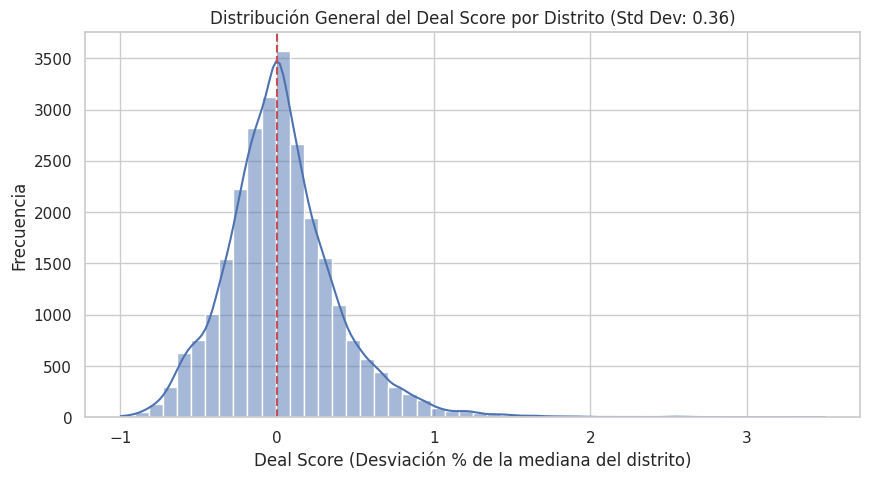

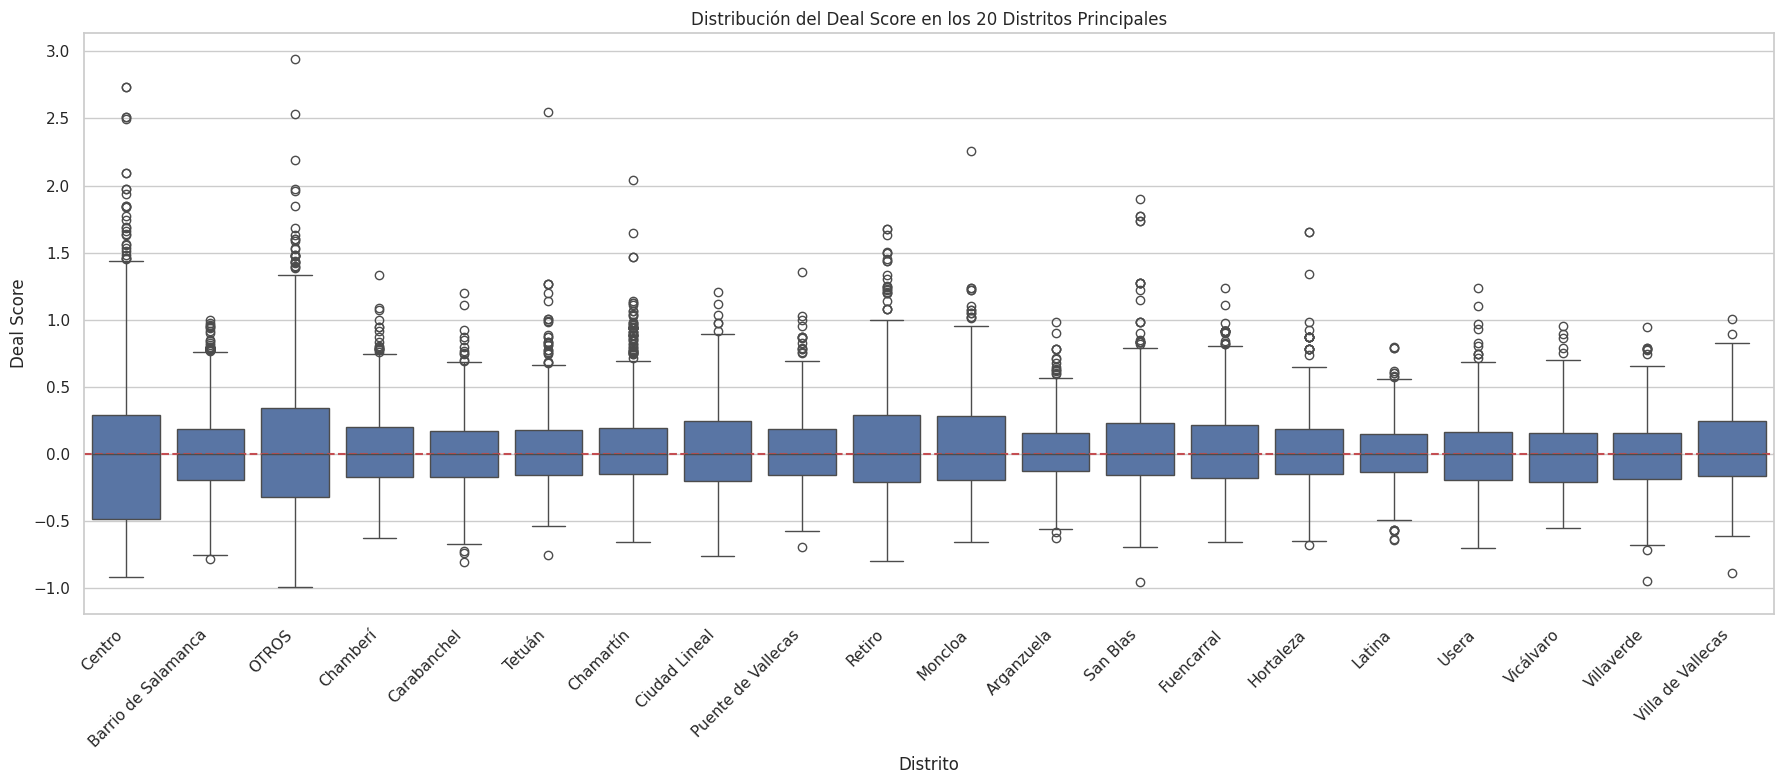

In [38]:
# Histograma de la distribución general
std_dev_district = df_limpios['deal_score_district'].std()

plt.figure(figsize=(10, 5))
sns.set(style="whitegrid")
sns.histplot(df_limpios['deal_score_district'], kde=True, bins=50)
plt.axvline(0, color='r', linestyle='--')
plt.title(f'Distribución General del Deal Score por Distrito (Std Dev: {std_dev_district:.2f})')
plt.xlabel('Deal Score (Desviación % de la mediana del distrito)')
plt.ylabel('Frecuencia')
plt.show()


# Boxplot para los 20 distritos principales

top_20_districts = df_limpios['district'].value_counts().nlargest(20).index
df_top_districts = df_limpios[df_limpios['district'].isin(top_20_districts)]

plt.figure(figsize=(18, 8))
ax = sns.boxplot(
    x='district',
    y='deal_score_district',
    data=df_top_districts,
    order=top_20_districts
)
ax.axhline(0, color='r', linestyle='--')
plt.title('Distribución del Deal Score en los 20 Distritos Principales')
plt.xlabel('Distrito')
plt.ylabel('Deal Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [39]:
#Visualización de los 15 distritos principales

top_15_districts = df_limpios['district'].value_counts().nlargest(15).index

# Mapa base
mapa_distritos = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# Paleta de colores y mapa de colores
colors = sns.color_palette('bright', n_colors=len(top_15_districts)).as_hex()
color_map = {district: colors[i] for i, district in enumerate(top_15_districts)}

# Añadir puntos al mapa
sample_size = min(len(df_limpios), 7000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    district = row['district']

    # Asignar color solo si el distrito está en nuestro top 15, si no, gris
    point_color = color_map.get(district, '#808080')

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=point_color,
        fill=True,
        fill_color=point_color,
        fill_opacity=0.7 if district in top_15_districts else 0.2,
        popup=f"Distrito: {district}"
    ).add_to(mapa_distritos)

# Crear y añadir leyenda
legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 220px; height: auto;
            border:2px solid grey; z-index:9999; font-size:12px;
            background-color:white; opacity: 0.9;
            ">&nbsp;<b>Leyenda: Top 15 Distritos</b><br>
'''

for district, color in color_map.items():
    legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color}"></i>&nbsp; {district}<br>'

legend_html += f'&nbsp; <i class="fa fa-circle" style="color:#D3D3D3"></i>&nbsp; Otros Distritos<br></div>'

mapa_distritos.get_root().html.add_child(folium.Element(legend_html))

mapa_distritos

Output hidden; open in https://colab.research.google.com to view.

### Conclusión y Selección de la Estrategia de Zonificación

Tras el análisis comparativo de las tres metodologías —*K-Means*, *DBSCAN* y segmentación por distritos—, se concluye que el agrupamiento mediante **K-Means con *k*=50** constituye la estrategia óptima para la ingeniería de la variable `deal_score`. La siguiente tabla sintetiza la evaluación:

| Criterio de Evaluación | K-Means (*k*=50) | DBSCAN | Segmentación por Distrito |
| :--- | :--- | :--- | :--- |
| **Granularidad de Zonas** | Óptima (50 clústeres homogéneos) | Deficiente (un clúster dominante) | Variable (zonas heterogéneas) |
| **Utilidad para `deal_score`** | Alta (referencias de precios locales) | Baja (referencia no representativa) | Limitada (solo en distritos homogéneos) |
| **Interpretabilidad** | Media (basada en coordenadas) | Alta (detección de anomalías) | Alta (límites administrativos) |

La superioridad de *K-Means* radica en su capacidad para generar micro-zonas que son a la vez granulares y presentan una alta homogeneidad interna en cuanto a precios. Esta característica es fundamental, ya que permite el cálculo de una mediana de referencia local y fiable para cada inmueble.

En contraste, la estructura generada por *DBSCAN* resultó ser demasiado heterogénea para un análisis de precios significativo. De manera similar, la segmentación por distritos, aunque interpretable, demostró una varianza de precios intra-zonal excesiva.

Por consiguiente, se valida la elección de la variable `deal_score_k50`, generada a partir de los clústeres de *K-Means*, como la variable objetivo a utilizar en la subsecuente fase de modelado predictivo.

## Conclusión de Feature Engineering: Guardado del Dataset Final

Concluida la fase de análisis y selección de la estrategia de zonificación, se procedió a la consolidación del conjunto de datos definitivo para el modelado.

Este proceso consistió en la selección de las características originales, las variables generadas mediante feature engineering y las columnas derivadas del agrupamiento óptimo: zona_cluster_k50 y deal_score_k50. Se eliminaron todas las columnas auxiliares empleadas durante la fase comparativa y, para estandarizar la nomenclatura, las columnas seleccionadas fueron renombradas a zona_cluster y deal_score.

Finalmente, el DataFrame resultante y depurado fue exportado a un nuevo archivo CSV (df_limpios_con_vd.csv), constituyendo el punto de partida validado para la subsecuente fase de modelado predictivo.

In [40]:
# Bloque Final: Preparación del Dataset para Modelado

# Definir la variable dependiente y la de zonificación ganadoras
target_col = 'deal_score_k50'
zone_col = 'zona_cluster_k50'

df_final_modelado = df_limpios.copy()

# Limpiar el dataframe de todos los otros clusters y deal_scores que generamos
cols_to_drop = [col for col in df_final_modelado.columns if ('_k' in col or '_dbscan' in col or '_district' in col) and col not in [target_col, zone_col]]
df_final_modelado.drop(columns=cols_to_drop, inplace=True)

# Renombrar columnas ganadoras
df_final_modelado.rename(columns={
    target_col: 'deal_score',
    zone_col: 'zona_cluster'
}, inplace=True)

# Guardar DataFrame final
output_filename = 'df_limpios_con_vd.csv'
df_final_modelado.to_csv(output_filename, index=False)

print(f"Dimensiones del DataFrame: {df_final_modelado.shape}")
print(f"Archivo '{output_filename}' guardado con éxito.")
print("\nColumnas finales:")
print(df_final_modelado.columns.tolist())

Dimensiones del DataFrame: (26261, 73)
Archivo 'df_limpios_con_vd.csv' guardado con éxito.

Columnas finales:
['bathrooms', 'detailedType.subTypology', 'detailedType.typology', 'district', 'exterior', 'floor', 'has360', 'has3DTour', 'hasLift', 'hasPlan', 'hasStaging', 'hasVideo', 'highlight.groupDescription', 'latitude', 'longitude', 'municipality', 'newDevelopment', 'newDevelopmentFinished', 'numPhotos', 'parkingSpace.hasParkingSpace', 'parkingSpace.isParkingSpaceIncludedInPrice', 'parkingSpace.parkingSpacePrice', 'price', 'priceByArea', 'priceInfo.price.priceDropInfo.priceDropPercentage', 'priceInfo.price.priceDropInfo.priceDropValue', 'propertyType', 'rooms', 'showAddress', 'size', 'status', 'topPlus', 'floor_cat', 'has_neighborhood', 'has_Discount', 'terraza', 'atico', 'garaje', 'ascensor', 'espaciosa', 'luminoso', 'reformado', 'obra_nueva', 'céntrico', 'interior', 'antiguo', 'a_reformar', 'sin_ascensor', 'okupa', 'oscuro', 'pequeño', 'mal_ubicado', 'cercano_metro', 'cercano_superm

### Interpretación y Relevancia de la Variable deal_score
La variable deal_score constituye una métrica de valor relativo, diseñada para cuantificar el posicionamiento de mercado de cada inmueble. Se calcula como la desviación porcentual del precio por metro cuadrado (priceByArea) de una propiedad con respecto a la mediana de su micromercado geográfico de referencia. Consecuentemente, un deal_score negativo indica que el activo se encuentra infravalorado en comparación con su entorno local, mientras que un valor positivo denota un sobreprecio.

La relevancia de esta variable radica en su capacidad para contextualizar el precio. Al normalizar el valor en función de la ubicación, se transforma el coste absoluto en una medida de "valor" relativo, permitiendo al modelo de aprendizaje profundo identificar patrones de oportunidad y sobrevaloración. Al condensar las complejas interacciones entre la geografía y el precio en un único indicador, el deal_score se erige como una característica de alto poder informativo y, por tanto, en un elemento central para la capacidad predictiva del modelo final.

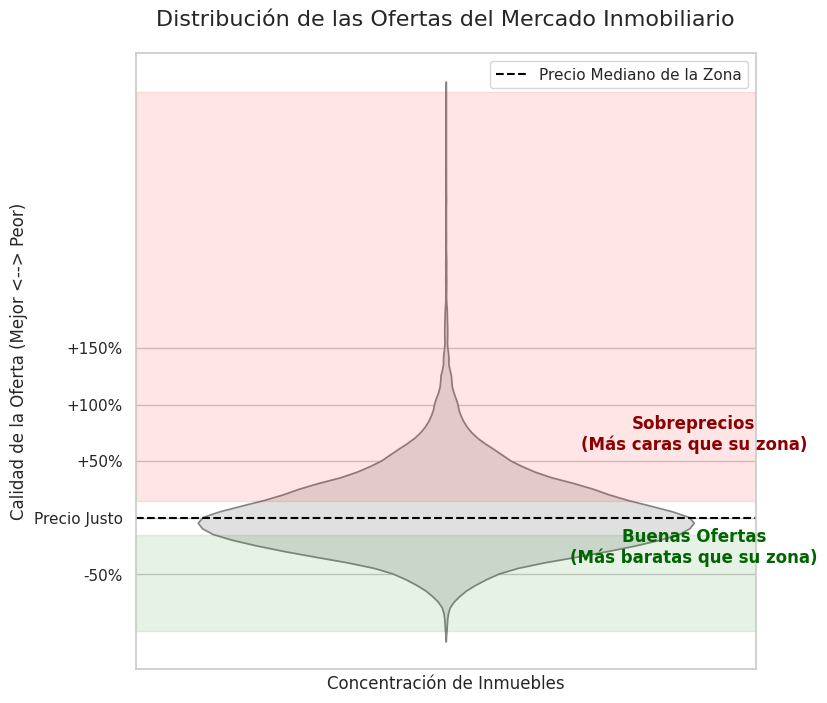

In [41]:
#Gráfico de Violín

plt.figure(figsize=(8, 8))
sns.set(style="whitegrid")

ax = sns.violinplot(y=df_limpios['deal_score_k50'], color='#E0E0E0', inner=None)

# Zona de "Buenas Ofertas" (verde)
ax.axhspan(ymin=df_limpios['deal_score_k50'].min(), ymax=-0.15, color='green', alpha=0.1)
plt.text(0.4, -0.4, 'Buenas Ofertas\n(Más baratas que su zona)', horizontalalignment='center', color='darkgreen', weight='bold')

# Zona de "Sobreprecios" (rojo)
ax.axhspan(ymin=0.15, ymax=df_limpios['deal_score_k50'].max(), color='red', alpha=0.1)
plt.text(0.4, 0.6, 'Sobreprecios\n(Más caras que su zona)', horizontalalignment='center', color='darkred', weight='bold')

# Línea de referencia en la mediana (cero)
ax.axhline(0, color='black', linestyle='--', label='Precio Mediano de la Zona')

# Títulos y etiquetas
plt.title('Distribución de las Ofertas del Mercado Inmobiliario', fontsize=16, pad=20)
plt.ylabel('Calidad de la Oferta (Mejor <--> Peor)')
plt.xlabel('Concentración de Inmuebles')

plt.xticks([])
plt.yticks([-0.5, 0, 0.5, 1.0, 1.5], ['-50%', 'Precio Justo', '+50%', '+100%', '+150%'])

plt.legend()
plt.show()

La distribución de la variable deal_score, tal y como se observa en la figura anterior, presenta una partición prácticamente equitativa en torno al cero (aproximadamente 50% de valores positivos y 50% negativos). Este resultado, si bien podría parecer contraintuitivo, es una consecuencia directa del uso de la mediana como pivote para el cálculo del deal_score. Por definición, la mediana divide cualquier distribución de datos en dos mitades de igual tamaño, lo que valida la robustez de la métrica frente a valores atípicos y garantiza una representación no sesgada de la posición relativa de cada activo.

La correcta interpretación de esta distribución requiere diferenciar entre la frecuencia de las observaciones y la magnitud de sus valores. Mientras que la frecuencia es simétrica por construcción, la tendencia del mercado hacia el sobreprecio se manifiesta en la asimetría de la magnitud. Como confirma el gráfico, la distribución de los valores positivos (deal_score > 0) exhibe una cola significativamente más larga que la de los valores negativos. Esto indica que, si bien el número de inmuebles infravalorados y sobrevalorados es similar, la magnitud de los sobreprecios tiende a ser considerablemente más extrema que la de los descuentos.

In [42]:
# Mapa de Calor del Deal Score

# Mapa base
mapa_deal_score_final = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# Escala de colores Verde-Amarillo-Rojo
min_score = -0.50
max_score = 0.50

colormap = LinearColormap(
    colors=['green', 'yellow', 'red'],
    index=[min_score, 0, max_score],
    vmin=min_score,
    vmax=max_score
)
colormap.caption = 'Deal Score (Verde = Buena Oferta, Rojo = Sobreprecio)'

# Añadir los puntos al mapa
sample_size = min(len(df_limpios), 5000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    score = row['deal_score_k50']
    score_clamped = max(min_score, min(score, max_score))

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=colormap(score_clamped),
        fill=True,
        fill_color=colormap(score_clamped),
        fill_opacity=0.7,
        popup=f"Deal Score: {score:.2%}<br>Precio/m²: {row['priceByArea']:,.0f} €"
    ).add_to(mapa_deal_score_final)

mapa_deal_score_final.add_child(colormap)

mapa_deal_score_final

Output hidden; open in https://colab.research.google.com to view.


### Análisis Geoespacial de la Variable `deal_score`

El análisis de la distribución geográfica del `deal_score` revela patrones consistentes con las dinámicas del mercado inmobiliario.

**Concentración de Sobreprecios en Zonas *Prime***

Se observa una densidad significativa de inmuebles sobrevalorados (`deal_score` > 0) en las zonas de mayor demanda, particularmente en los distritos de la almendra central de Madrid. Este patrón es coherente con mercados consolidados donde la oferta limitada y la alta competencia justifican un *premium* sobre el precio mediano, asociado a la exclusividad o a calidades superiores del activo.

**Ocurrencia de Activos Infravalorados en la Periferia**

En contraposición, los activos infravalorados (`deal_score` < 0) se localizan con mayor frecuencia en los distritos periféricos y en áreas en transición socioeconómica. Este fenómeno puede atribuirse a una mayor volatilidad y sensibilidad al precio en estos mercados, donde factores como la necesidad de reformas o la urgencia del vendedor pueden generar precios por debajo de la mediana de referencia local.

**Interpretación del Valor Relativo**

Es fundamental subrayar que el `deal_score` representa una medida de valor relativo, no absoluto. El mapa visualiza el posicionamiento de un activo respecto a su micromercado. Por ello, es metodológicamente coherente la existencia de activos infravalorados en distritos de alto valor. Un inmueble en una zona *prime*, aunque elevado en precio absoluto, puede estar cotizando por debajo de la mediana local debido a características específicas, constituyendo así una oportunidad relativa dentro de su propio segmento de mercado.